In [2]:
#impots
import os
import scipy.sparse as sp
from scipy.sparse import coo_matrix
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import eig
from sympy import composite

## **Generating graph and then calculating the epi threshold**


generate graph statistcs based on gravity theory

In [45]:
def radiation_model(number_nodes, positions, population):

    rows,cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1


        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        #change self flow


        all_flows = []
        for j in range(number_nodes):
            if j == i:
                 flow = np.random.uniform(0.25, 0.40) * population[i] #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0,  s_ij) #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    log_flow = np.log(population[i]) + np.log(first_term) - np.log(second_term)
                    flow = np.exp(log_flow)

            all_flows.append(flow)



       #urban scaling theory geoffery west luisbettern court
        # target_k = number_nodes * 0.08
        # k = int(target_k * (population [i]  / np.mean(population))**0.5) #scale based on popualtion
        # k= np.clip(k, 1, 500)
        # top_idx = np.argpartition(all_flows, -k)[-k:]
        # #print(k)


        k = np.random.uniform(0.01, 0.08)
        k= int(k * number_nodes)



        top_idx = np.argpartition(all_flows, -k)[-k:]

        for j in top_idx:
            rows.append(i)
            cols.append(j)
            weights.append(all_flows[j])

        #print(flow)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [43]:
def gravity_hubs(number_nodes, positions, population, gamma = 0.4):
    rows,cols, weights = [], [], []

    hubs_idx = np.argsort(population)[- int(number_nodes * 0.05):] #top 5%

    for i in hubs_idx:
        hub_positions = positions[hubs_idx]
        hub_population = population[hubs_idx]

        distances = np.sqrt(((hub_positions[i] - hub_positions) ** 2).sum(axis=1))
        distances[i] = np.inf
        distances[distances == 0] = 0.1

        #attraction = g * (m * m) / d^gamma
        flow = (hub_population[i] * hub_population) / (distances ** gamma)
        flow[i] = 0
        flow = np.asarray(flow).flatten()

        for local_idx, f in enumerate(flow):
            global_j = hubs_idx[local_idx]
            if global_j != i and f > 0:
                rows.append(i)
                cols.append(global_j)
                weights.append(f)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows]


    return np.array(rows), np.array(cols), np.array(weights)



In [42]:


def generate_graph(total_population, number_nodes, area, alpha = 0.2):

   #zipfs law fore reaslitc cities

    gamma = 0.55
    decay_rate = 0.0028
    rank = np.arange(1, number_nodes + 1)
    zipf_term = 1 / ( rank ** gamma)
    exponential_term = np.exp(-decay_rate * rank)
    noise = np.random.lognormal(0, 0.05, number_nodes)




    population_distribution = zipf_term  * exponential_term * noise

    population = ((population_distribution / population_distribution.sum()) * total_population).astype(int)
    population[0] += total_population - population.sum()

    #population = np.full(number_nodes, total_population // number_nodes)

    side_length = np.sqrt(area)
    positions = np.random.rand(number_nodes, 2) * side_length

    # side = np.sqrt(area)
    # cluster_centres = np.random.rand(number_nodes, 2) * side
    # positions = np.array([
    #     np.clip(cluster_centres[i % number_nodes] + np.random.randn(2) * side * 0.08, 0, side)
    #     for i in range(number_nodes)])

    rows, cols, weights = radiation_model(number_nodes, positions, population)
    #hub_rows, hub_cols, hub_weights = gravity_hubs(number_nodes, positions, population)

    #create graph
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
    graph = graph.tocsr()

    #hub_graph = coo_matrix((hub_weights, (hub_rows, hub_cols)), shape=(number_nodes, number_nodes))
    #hub_graph = hub_graph.tocsr()

    composite_graph = (1 - alpha) * graph  #+ alpha * hub_graph



    return composite_graph,  population, positions


visualse graph

In [9]:


def visualise_graph(graph):
    graph = nx.from_scipy_sparse_array(graph)

    # threshold = 0.5  # Example threshold
    # elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > threshold]

    # 3. Draw
    pos = nx.spring_layout(graph, seed=42)  # Positions for all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=10)
    nx.draw_networkx_edges(graph, pos, width=0.1, alpha=0.5)

    plt.title("Flow Graph")
    plt.show()



calculate matrix M

In [41]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3



call functions and calculate spectral radius --> epidemic threshold

In [40]:
def devide_area(population, total_area):
    log_population = np.log1p(population)
    area_distr = (log_population/np.sum(log_population)) * total_area
    return area_distr

In [39]:


def calculate_threshold(graph, population, total_area, recovery_rate, mobility_rate = 1):
    #graph,population,positions = generate_graph(total_population, number_nodes, total_area)
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist
    # log_population = np.log1p(population)
    # area_distr = (log_population/np.sum(log_population)) * total_area

    area_distr = devide_area(population, total_area)


    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    #print(spectral_radius)

    #print(recovery_rate / spectral_radius)


    return recovery_rate / spectral_radius

#generate_data(5600000, 4774, 350, 1, 1)
#calculate_threshold(312969665, 3574052, 3220, 1, 1)


In [29]:
import scipy.sparse as sp
graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=3219, alpha=0)
#graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=3220, alpha=0)
 #gamma = 0.55
    #decay_rate = 0.0028
# Assuming 'graph' is your csr_matrix
#sp.save_npz('radiation_newtest2.npz', graph)


#graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=302, alpha=0.5)



#graph, population, position = generate_graph(total_population=6000000, area=2000, number_nodes=150, alpha=0) #miami


In [34]:
np.savez_compressed('testing graphs/mobility_metadata_newtest2.npz',
                    population=population,
                    positions=position)

In [32]:
threshold = calculate_threshold(graph, population = population, total_area = 3574052, recovery_rate = 1, mobility_rate = 1)
threshold

KeyboardInterrupt: 

In [ ]:
population.min()

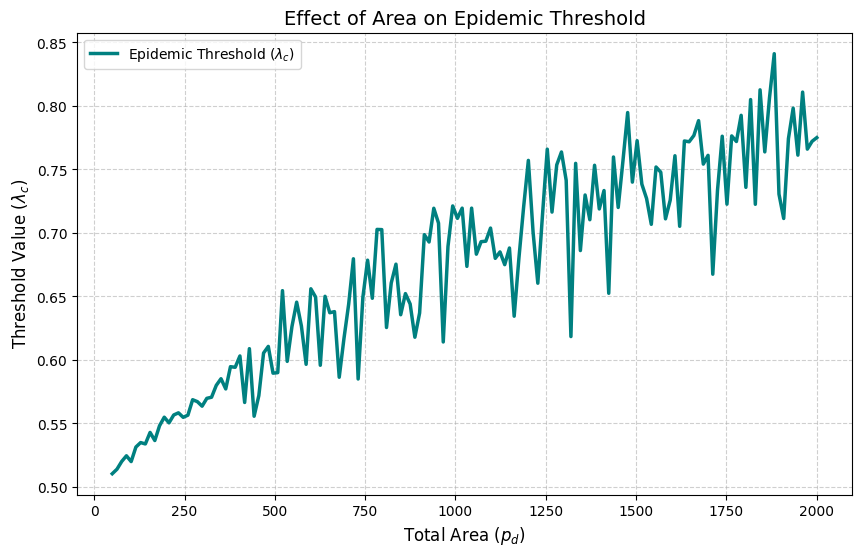

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the range of mobility rates (0 to 1)
areas = np.linspace(50, 2000, 150)
thresholds = []

# 2. Loop through and call your function
for area in areas:
    # We call your function, updating only the mobility_rate each time

    graph, population, position = generate_graph(total_population=1000000, area=area, number_nodes=150, alpha=0)

    t = calculate_threshold(
        graph,
        population=population,
        total_area=area,
        recovery_rate=1,
        mobility_rate=1
    )
    thresholds.append(t)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(areas, thresholds, color='teal', linewidth=2.5, label='Epidemic Threshold ($\lambda_c$)')

# Formatting the graph
plt.title('Effect of Area on Epidemic Threshold', fontsize=14)
plt.xlabel('Total Area ($p_d$)', fontsize=12)
plt.ylabel('Threshold Value ($\lambda_c$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

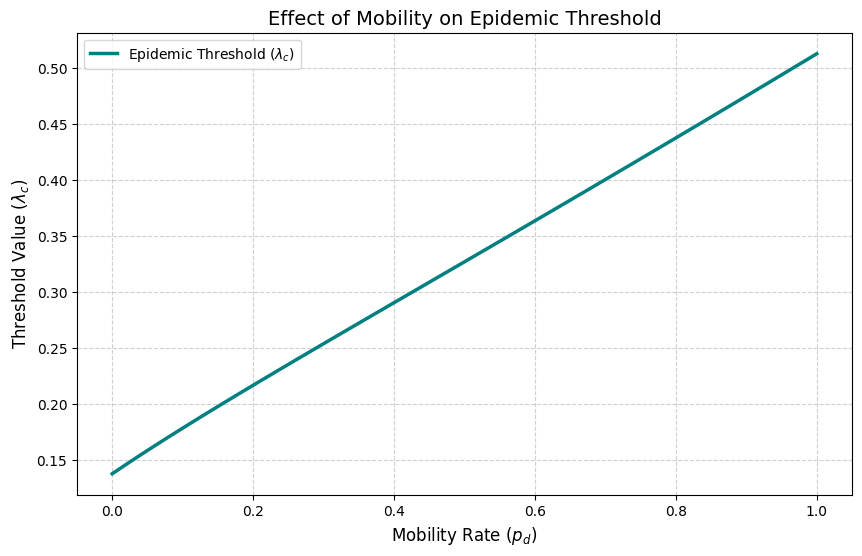

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the range of mobility rates (0 to 1)
mobility_rates = np.linspace(0, 1, 50)
thresholds = []

graph, population, position = generate_graph(total_population=6000000, area=2000, number_nodes=400, alpha = 0)

# 2. Loop through and call your function
for rate in mobility_rates:
    # We call your function, updating only the mobility_rate each time
    t = calculate_threshold(
        graph,
        population=population,
        total_area=2000,
        recovery_rate=1,
        mobility_rate=rate
    )
    thresholds.append(t)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(mobility_rates, thresholds, color='teal', linewidth=2.5, label='Epidemic Threshold ($\lambda_c$)')

# Formatting the graph
plt.title('Effect of Mobility on Epidemic Threshold', fontsize=14)
plt.xlabel('Mobility Rate ($p_d$)', fontsize=12)
plt.ylabel('Threshold Value ($\lambda_c$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

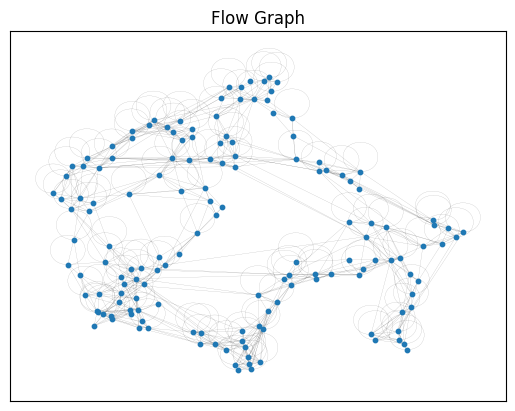

In [200]:
visualise_graph(graph)

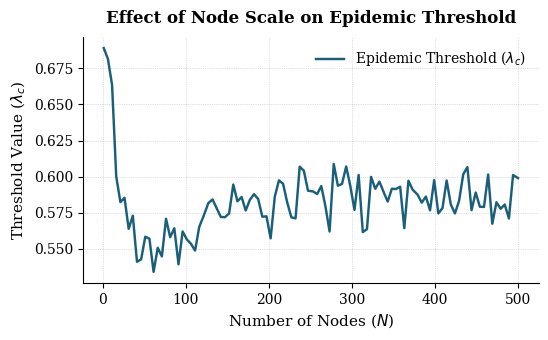

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# --- ACADEMIC STYLING CONFIGURATION ---
# Use standard serif fonts (matches LaTeX / Times New Roman papers)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = False  # Set to True if you have LaTeX installed locally

# Adjust font sizes for legibility in print layouts
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# 1. Define data range
nodes = np.linspace(1, 500, 100).astype(int)
thresholds = []

# 2. Simulate data loop
for node in nodes:
    graph, population, position = generate_graph(total_population=6000000, area=2000, number_nodes=node, alpha=0)
    t = calculate_threshold(
        graph,
        population=population,
        total_area=2000,
        recovery_rate=1,
        mobility_rate=1
    )
    thresholds.append(t)

# 3. Create the Academic-Grade Plot
# 5.5 x 3.5 inches is an ideal size for single-column figures in journals
fig, ax = plt.subplots(figsize=(5.5, 3.5))

# Use a clean, professional color (dark muted teal or slate gray)
ax.plot(nodes, thresholds, color='#1a5f7a', linewidth=1.75, label=r'Epidemic Threshold ($\lambda_c$)')

# Academic formatting adjustments
ax.set_title('Effect of Node Scale on Epidemic Threshold', weight='bold', pad=10)
ax.set_xlabel('Number of Nodes ($N$)')
ax.set_ylabel(r'Threshold Value ($\lambda_c$)')

# Minimalist, clean boundaries (removes the aggressive bounding box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subdued grid style (light lines so they sit in the background)
ax.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.5)

# Place the legend cleanly without a heavy border frame
ax.legend(loc='upper right', frameon=False)

# Optimize spatial layout
plt.tight_layout()

# 4. Save in publication quality (Vector PDF or high-DPI PNG)
# Always use vector format (PDF/EPS) for papers if possible, otherwise 300+ DPI PNG.
# plt.savefig('epidemic_threshold_nodes.pdf', format='pdf', bbox_inches='tight')
plt.savefig('epidemic_threshold_nodes.png', dpi=300, bbox_inches='tight')

plt.show()

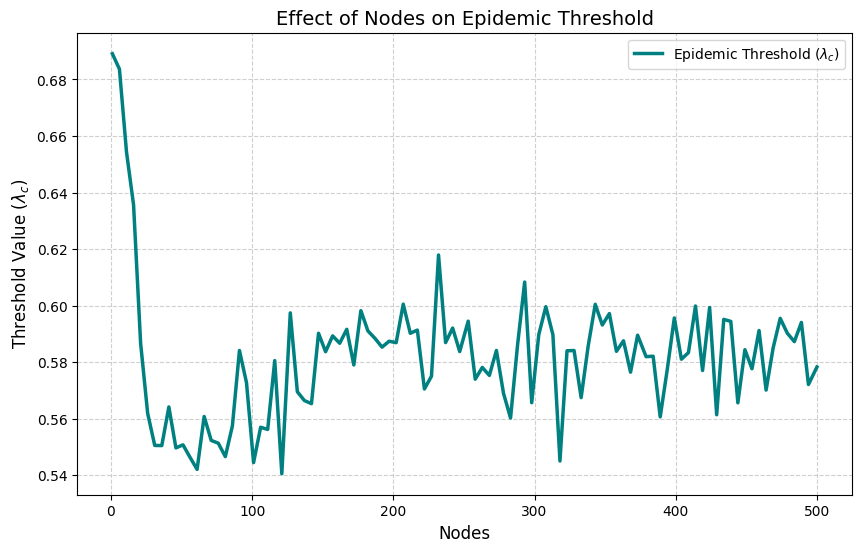

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the range of mobility rates (0 to 1)
nodes = np.linspace(1, 500, 100).astype(int)
thresholds = []



# 2. Loop through and call your function
for node in nodes:
    # We call your function, updating only the mobility_rate each time
    graph, population, position = generate_graph(total_population=6000000, area=2000, number_nodes=node, alpha=0)
    t = calculate_threshold(
        graph,
        population=population,
        total_area=2000,
        recovery_rate=1,
        mobility_rate=1
    )
    thresholds.append(t)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(nodes, thresholds, color='teal', linewidth=2.5, label='Epidemic Threshold ($\lambda_c$)')

# Formatting the graph
plt.title('Effect of Nodes on Epidemic Threshold', fontsize=14)
plt.xlabel('Nodes', fontsize=12)
plt.ylabel('Threshold Value ($\lambda_c$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

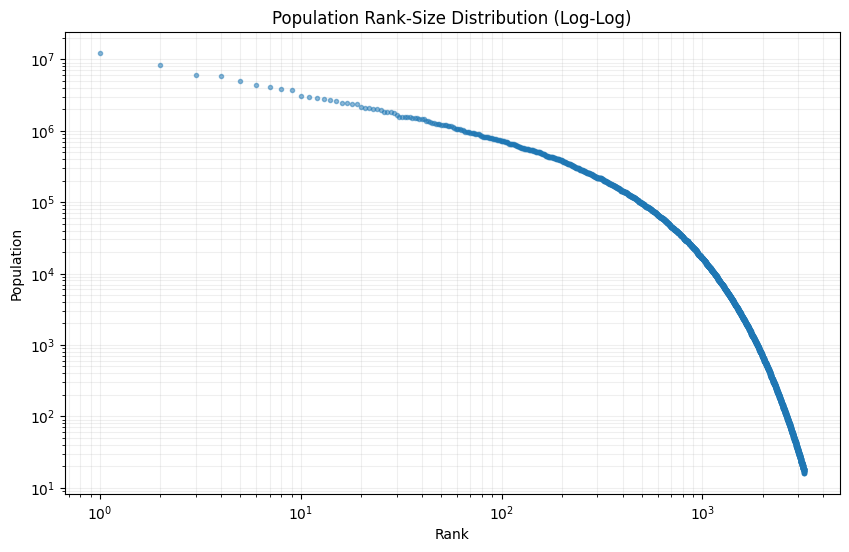

In [395]:
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_pop, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.xlabel("Rank")
plt.ylabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [36]:
number_nodes= 938
total_population=8064392

#0.55, ).0028
gamma = 0.51
decay_rate = 0.0008
rank = np.arange(1, number_nodes + 1)
zipf_term = 1 / ( rank ** gamma)
exponential_term = np.exp(-decay_rate * rank)
noise = np.random.lognormal(0, 0.05, number_nodes)



population_distribution = zipf_term * exponential_term * noise

population = ((population_distribution / population_distribution.sum()) * total_population).astype(int)
#population = np.maximum(population, 50)
population[0] += total_population - population.sum()

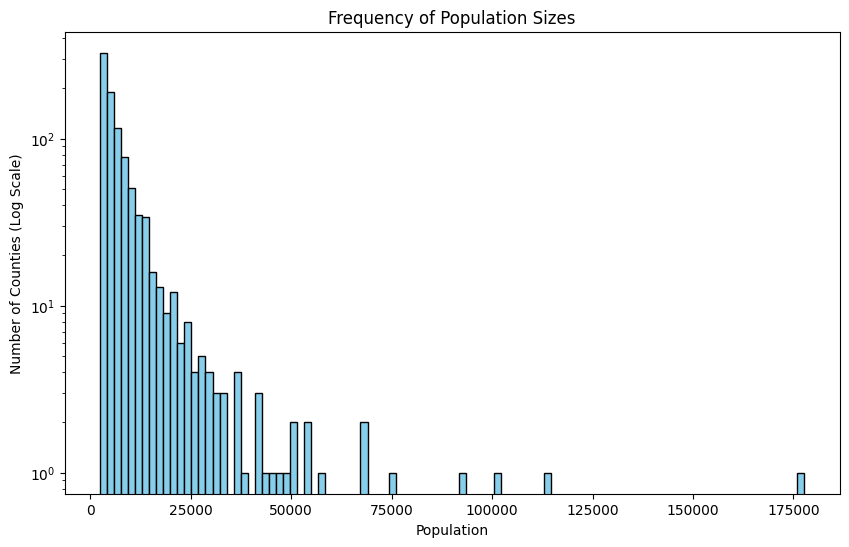

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Counties (Log Scale)")
plt.show()

In [209]:
population.max()

10554477

In [21]:
import torch
from torch_geometric.data import Data
import numpy as np
import os

def generate_and_save_dataset(num_graphs=10):
    all_graphs = {}
    all_features =  {}
    all_thresholds = []

    output_dir = 'datasets/version1'
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving to: {os.path.abspath(output_dir)}")

    for i in range(num_graphs):

        total_population = np.random.randint(1000000, 15000000)  # populatuon  large cities
        number_nodes= np.random.randint(350, 900) #number of zip, codes
        total_area = np.random.randint(1500, 6000) #between 4000 and 15000 sq km in miles
        recovery_rate= 1


        graph, population, position = generate_graph(total_population, number_nodes,total_area, alpha=0)

        graph_coo = graph.tocoo()

        all_graphs[f'row_{i}'] = graph_coo.row
        all_graphs[f'col_{i}'] = graph_coo.col
        all_graphs[f'data_{i}'] = graph_coo.data

    # Store features as (N, 3) arrays
        all_features[f'feat_{i}'] = np.column_stack((population, position))

        threshold = calculate_threshold(graph, population, total_area, recovery_rate)
        all_thresholds.append(threshold)

        # sp.save_npz(f'{output_dir}/graph_{i}.npz', graph)
        #
        # node_data = np.column_stack((population, position))
        # np.save(f'{output_dir}/features_{i}.npy', node_data)
        #

        # np.save(f'{output_dir}/threshold_{i}.npy', threshold)

        if i % 10 == 0:
            print(f"Generated {i} graphs...")

    save_path = os.path.join(output_dir, 'testing3.npz')
    np.savez_compressed(save_path, **all_graphs, **all_features, thresholds=np.array(all_thresholds))

In [22]:
generate_and_save_dataset(20)

Saving to: /Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1
Generated 0 graphs...
Generated 10 graphs...


In [24]:
import torch
from torch_geometric.data import Data
import numpy as np
import os


def generate_and_save_dataset_pyg(num_graphs=10):
    all_graphs = {}
    all_features = {}
    all_thresholds = []

    output_dir = 'datasets/version1'
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving to: {os.path.abspath(output_dir)}")

    pyg_graphs = []

    for i in range(num_graphs):
        #usa cities
        total_population = np.random.randint(1000000, 15000000)  # population large cities
        number_nodes = np.random.randint(350, 900) # number of zip codes
        total_area = np.random.randint(1500, 6000) # between 4000 and 15000 sq km in miles
        recovery_rate = 1

        #testing with smaller graphs
        # total_population = np.random.randint(100000, 5000000)  # population large cities
        # number_nodes = np.random.randint(50, 200) # number of zip codes
        # total_area = np.random.randint(150, 1500) # between 4000 and 15000 sq km in miles
        # recovery_rate = 1

        # Generate your raw data
        graph, population, position = generate_graph(total_population, number_nodes, total_area, alpha=0)
        graph_coo = graph.tocoo()
        threshold = calculate_threshold(graph, population, total_area, recovery_rate)
        area_distr = devide_area(population, total_area)

        # --- Convert directly to PyTorch Tensors ---

        # 1. edge_index: Shape [2, num_edges], type int64 (long)
        edge_index = torch.tensor(np.vstack((graph_coo.row, graph_coo.col)), dtype=torch.long)

        # 2. edge_attr: Shape [num_edges, 1], type float32
        edge_attr = torch.tensor(graph_coo.data, dtype=torch.float32).view(-1, 1)

        # 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
        node_features = np.column_stack((population, position, area_distr))
        x = torch.tensor(node_features, dtype=torch.float32)

        # 4. y (Target label): Shape [1], type float32
        y = torch.tensor([threshold], dtype=torch.float32)

        # --- Construct PyG Data Object ---
        data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

        # Append to our list
        pyg_graphs.append(data_obj)

        if i % 10 == 0:
            print(f"Generated {i} graphs...")


    save_path = os.path.join(output_dir, '1000biggraphs.pt')

    # torch.save can save entire lists of PyG Data objects natively!
    torch.save(pyg_graphs, save_path)
    print(f"Successfully saved {len(pyg_graphs)} PyG graphs to {save_path}")

In [ ]:
aerea = devide_area(populatio)

In [25]:
generate_and_save_dataset_pyg(1000)

Saving to: /Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1
Generated 0 graphs...
Generated 10 graphs...
Generated 20 graphs...
Generated 30 graphs...
Generated 40 graphs...
Generated 50 graphs...
Generated 60 graphs...
Generated 70 graphs...
Generated 80 graphs...
Generated 90 graphs...
Generated 100 graphs...
Generated 110 graphs...
Generated 120 graphs...
Generated 130 graphs...
Generated 140 graphs...
Generated 150 graphs...
Generated 160 graphs...


KeyboardInterrupt: 

In [19]:
graph, population, position = generate_graph(total_population=500000, area=150, number_nodes=150, alpha=0)

In [20]:
threshold = calculate_threshold(graph, population, 150, 1 ,1 )
threshold

0.6380983235856875

In [18]:
import torch
from torch_geometric.data import Data
import numpy as np
import os

graph = graph.tocoo()

edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

# 2. edge_attr: Shape [num_edges, 1], type float32
edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

# 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32


# 4. y (Target label): Shape [1], type float32
#y = torch.tensor([threshold], dtype=torch.float32)

# --- Construct PyG Data Object ---
data_obj = Data(population=population, edge_index=edge_index, edge_attr=edge_attr, number_nodes = 150)

# Append to our list
pyg_graph = data_obj

save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/montecarlosmaller.pt'

torch.save(pyg_graph, save_path)
